In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_churn.csv")

df.head()
df.shape

(7032, 21)

In [3]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [4]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [5]:
contract_churn = (
    df.groupby("Contract")["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .reset_index(name="churn_rate")
      .sort_values("churn_rate", ascending=False)
)

contract_churn

,Contract,churn_rate
0,Month-to-month,42.709677
1,One year,11.277174
2,Two year,2.848665


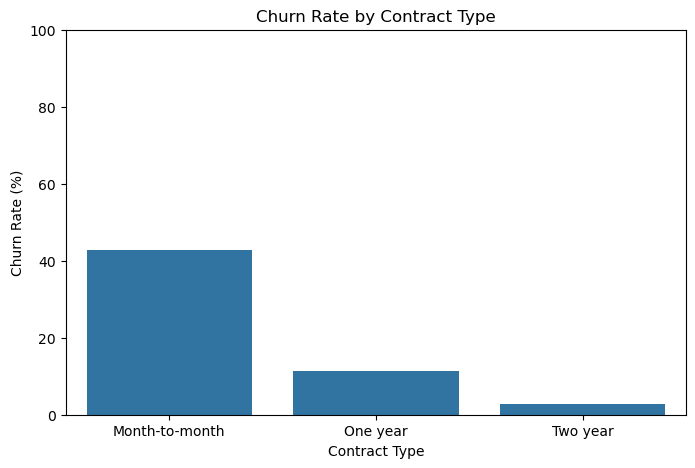

In [6]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_churn,
    x="Contract",
    y="churn_rate"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.show()

In [9]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

In [10]:
tenure_churn = (
    df.groupby("tenure_group", observed=False)["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .reset_index(name="churn_rate")
)

tenure_churn

,tenure_group,churn_rate
0,0-6 months,53.333333
1,7-12 months,35.886525
2,13-24 months,28.710938
3,25-48 months,20.388959
4,49-72 months,9.513176


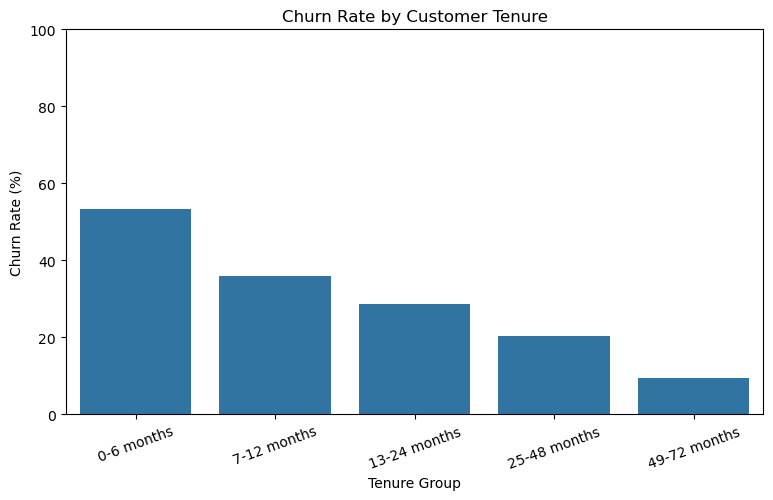

In [11]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn,
    x="tenure_group",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.show()

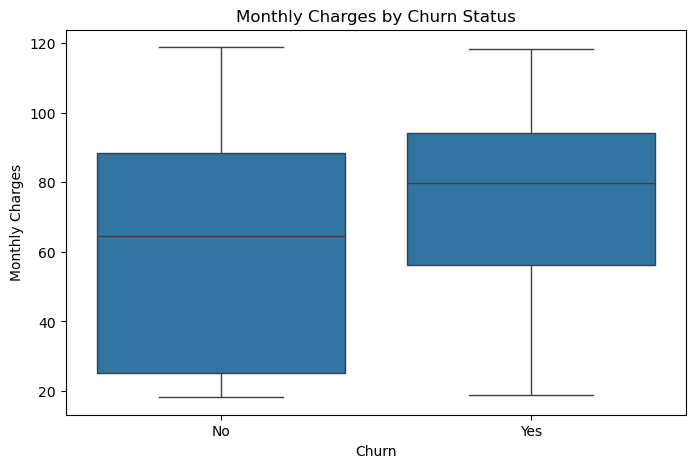

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [13]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Churn,,,,,
No,5163,61.307408,64.45,18.25,118.75
Yes,1869,74.441332,79.65,18.85,118.35


In [14]:
internet_churn = (
    df.groupby("InternetService")["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .reset_index(name="churn_rate")
      .sort_values("churn_rate", ascending=False)
)

internet_churn

,InternetService,churn_rate
1,Fiber optic,41.892765
0,DSL,18.998344
2,No,7.434211


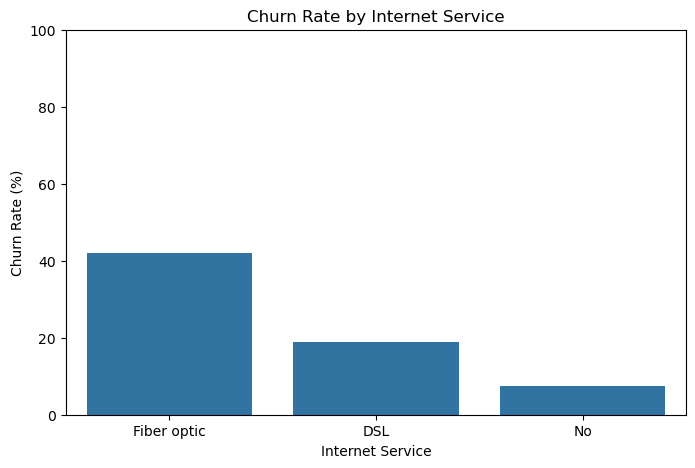

In [15]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=internet_churn,
    x="InternetService",
    y="churn_rate"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.show()

In [16]:
support_churn = (
    df.groupby("TechSupport")["Churn"]
      .apply(lambda values: (values == "Yes").mean() * 100)
      .reset_index(name="churn_rate")
      .sort_values("churn_rate", ascending=False)
)

support_churn

,TechSupport,churn_rate
0,No,41.647465
2,Yes,15.196078
1,No internet service,7.434211


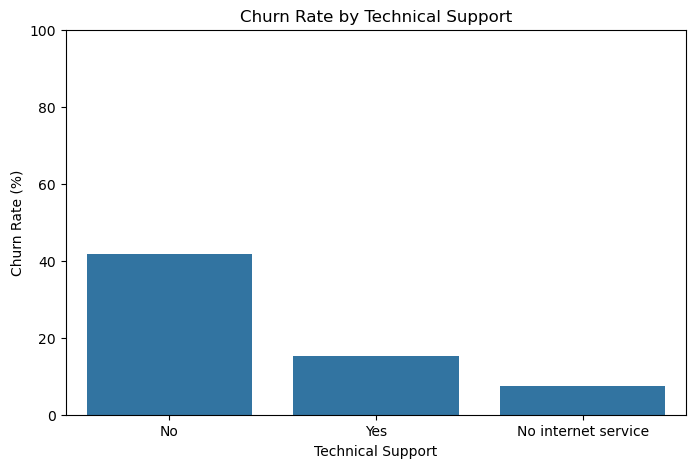

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=support_churn,
    x="TechSupport",
    y="churn_rate"
)

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.show()